In [ ]:
#|default_exp sgd

# Accelerated SGD

In [ ]:
# import sys
# sys.path.insert(0, '/app/data/deeplearning/course22p2_zh/')

In [ ]:
import sys
sys.path.insert(0, '/home/tzyy/projects/course22p2_zh')

In [ ]:
#|export
import torch

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

In [ ]:
import pickle,gzip,math,os,time,shutil,torch,matplotlib as mpl,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter,itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

import torchvision.transforms.functional as TF,torch.nn.functional as F
from torch import tensor,nn,optim
from torch.utils.data import DataLoader,default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset,load_dataset_builder

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *

In [ ]:
from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
torch.manual_seed(1)

import logging
logging.disable(logging.WARNING)

set_seed(42)

In [ ]:
xl,yl = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)

bs = 1024
xmean,xstd = 0.28, 0.35

@inplace
def transformi(b): b[xl] = [(TF.to_tensor(o)-xmean)/xstd for o in b[xl]]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)

In [ ]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
astats = ActivationStats(fc.risinstance(GeneralRelu))
cbs = [DeviceCB(), metrics, ProgressCB(plot=False), astats]
act_gr = partial(GeneralRelu, leak=0.1, sub=0.4)
iw = partial(init_weights, leaky=0.1)
lrf_cbs = [DeviceCB(), LRFinderCB()]

## Optimizers

### SGD

In [ ]:
class SGD:
    def __init__(self, params, lr, wd=0.):
        params = list(params)
        fc.store_attr()
        self.i = 0

    def step(self):
        with torch.no_grad():
            for p in self.params:
                self.reg_step(p)
                self.opt_step(p)
        self.i +=1

    def opt_step(self, p): p -= p.grad * self.lr
    def reg_step(self, p):
        if self.wd != 0: p *= 1 - self.lr*self.wd

    def zero_grad(self):
        for p in self.params: p.grad.data.zero_()

In [ ]:
MomentumLearner??

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.4, cbs=cbs, opt_func=SGD)

In [ ]:
learn.fit(3)

accuracy,loss,epoch,train
0.805,0.539,0,train
0.847,0.414,0,eval
0.871,0.348,1,train
0.863,0.371,1,eval
0.887,0.303,2,train
0.878,0.337,2,eval


In [ ]:
learn = MomentumLearner(model, dls, F.cross_entropy, lr=0.05, cbs=cbs, opt_func=SGD)
learn.fit(2)

accuracy,loss,epoch,train
0.907,0.251,0,train
0.887,0.305,0,eval
0.913,0.241,1,train
0.892,0.299,1,eval


Consider the difference between *weight decay* and *L2 regularization*:

``` python
weight -= lr*wd*weight
```

...vs...

``` python
weight.grad += wd*weight
```

### Momentum

In [ ]:
xs = torch.linspace(-4, 4, 100)
ys = 1 - (xs/3) ** 2 + torch.randn(100) * 0.1

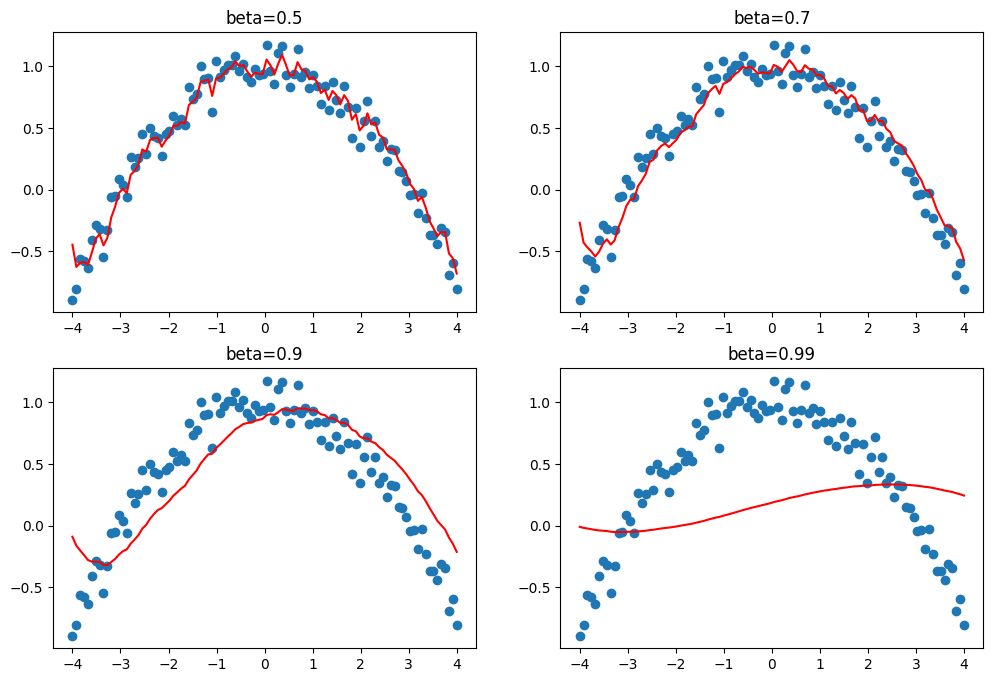

In [ ]:
_,axs = plt.subplots(2,2, figsize=(12,8))
betas = [0.5,0.7,0.9,0.99]
for beta,ax in zip(betas, axs.flatten()):
    ax.scatter(xs,ys)
    avg,res = 0,[]
    for yi in ys:
        avg = beta*avg + (1-beta)*yi
        res.append(avg)
    ax.plot(xs,np.array(res), color='red');
    ax.set_title(f'beta={beta}')

In [ ]:
class Momentum(SGD):
    def __init__(self, params, lr, wd=0., mom=0.9):
        super().__init__(params, lr=lr, wd=wd)
        self.mom=mom

    def opt_step(self, p):
        if not hasattr(p, 'grad_avg'): p.grad_avg = torch.zeros_like(p.grad)
        p.grad_avg = p.grad_avg*self.mom + p.grad*(1-self.mom)
        p -= self.lr * p.grad_avg

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=1.5, cbs=cbs, opt_func=Momentum)

In [ ]:
learn.fit(3)

accuracy,loss,epoch,train
0.787,0.596,0,train
0.847,0.416,0,eval
0.869,0.359,1,train
0.860,0.370,1,eval
0.886,0.313,2,train
0.869,0.357,2,eval


In [ ]:
learn = TrainLearner(model, dls, F.cross_entropy, lr=0.01, cbs=cbs, opt_func=Momentum)
learn.fit(2)

accuracy,loss,epoch,train
0.897,0.280,0,train
0.881,0.333,0,eval
0.901,0.273,1,train
0.881,0.329,1,eval


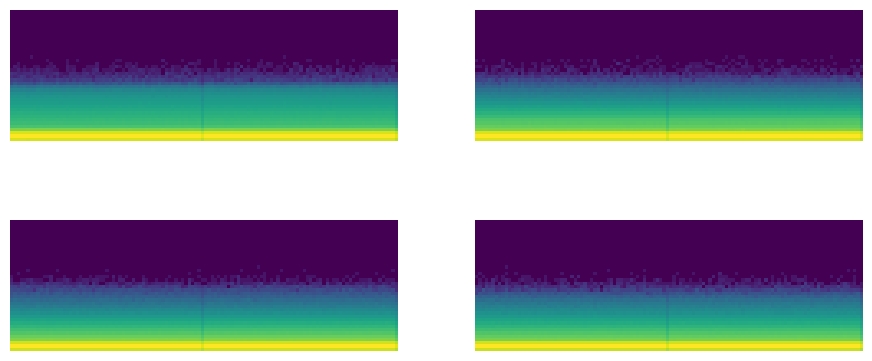

In [ ]:
astats.color_dim()

In [ ]:
clean_mem()

### RMSProp

In [ ]:
class RMSProp(SGD):
    def __init__(self, params, lr, wd=0., sqr_mom=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.sqr_mom,self.eps = sqr_mom,eps

    def opt_step(self, p):
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = p.grad**2
        p.sqr_avg = p.sqr_avg*self.sqr_mom + p.grad**2*(1-self.sqr_mom)
        p -= self.lr * p.grad/(p.sqr_avg.sqrt() + self.eps)

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=3e-3, cbs=cbs, opt_func=RMSProp)
learn.fit(3)

accuracy,loss,epoch,train
0.765,0.665,0,train
0.823,0.481,0,eval
0.848,0.416,1,train
0.846,0.426,1,eval
0.866,0.367,2,train
0.850,0.403,2,eval


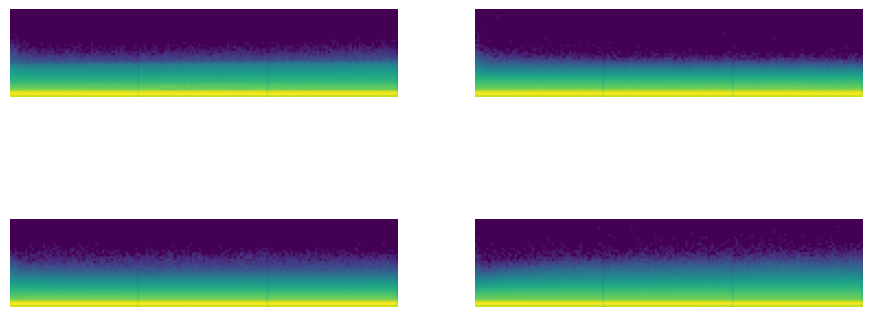

In [ ]:
astats.color_dim()

In [ ]:
clean_mem()

为什么RMSProp的学习率要设置这么小，不能像Moment一样

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！根本原因在于 **梯度被归一化后的尺度不同**。

## 有没有发现一个关键区别？

回顾一下两个优化器的更新公式：

**Momentum（动量 SGD）**
```
p -= lr * grad_avg
```
这里 `grad_avg` 保留了梯度的**原始大小**。如果梯度本身很小（比如 0.01），那每一步的实际移动就是 `lr × 0.01`。所以你可以把 lr 设到 0.01 甚至 1.5 —— 因为有梯度幅度的"天然衰减"。

**RMSProp**
```
p -= lr * grad / sqrt(sqr_avg + eps)
```
这里的 `grad / sqrt(sqr_avg)` 是**归一化后的值**。因为 `sqr_avg` 近似 `grad²`，所以这个比值大约就是 ±1（正负号决定方向）。换句话说，RMSProp 把梯度**压缩到了差不多 ±1 的量级**。

## 实际效果对比

| | 典型梯度幅度 | 有效步长 |
|--|--|--|
| Momentum | 0.01~0.1 | lr × (0.01~0.1) |
| RMSProp | ≈1（归一化后） | ≈ lr |

所以用 Momentum 时 lr=0.01，实际步长是 ~0.0001~0.001；用 RMSProp 时同样的 lr=0.01，实际步长是 ~0.01 —— **大了 10~100 倍**。这就是为什么 RMSProp（及其后继者 Adam）的默认学习率通常设在 1e-3 到 3e-4 这个量级，而 SGD/Momentum 可以用 0.01~0.1。

想试试把 RMSProp 的 lr 调到 0.01 或 0.1，看看会发生什么吗？

<details class='token-usage-details' markdown='1'><summary>$0.0018</summary>

`total=14,005 | in=12,962 | out=1,043 | cached=50.4% | reasoning=635 | searches=0 | $0.0018`

</details>


### Adam

In [ ]:
class Adam(SGD):
    def __init__(self, params, lr, wd=0., beta1=0.9, beta2=0.99, eps=1e-5):
        super().__init__(params, lr=lr, wd=wd)
        self.beta1,self.beta2,self.eps = beta1,beta2,eps

    def opt_step(self, p):
        if not hasattr(p, 'avg'): p.avg = torch.zeros_like(p.grad.data)
        if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)
        p.avg = self.beta1*p.avg + (1-self.beta1)*p.grad
        unbias_avg = p.avg / (1 - (self.beta1**(self.i+1)))
        p.sqr_avg = self.beta2*p.sqr_avg + (1-self.beta2)*(p.grad**2)
        unbias_sqr_avg = p.sqr_avg / (1 - (self.beta2**(self.i+1)))
        p -= self.lr * unbias_avg / (unbias_sqr_avg + self.eps).sqrt()

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=6e-3, cbs=cbs, opt_func=Adam)
learn.fit(3)

accuracy,loss,epoch,train
0.791,0.583,0,train
0.839,0.428,0,eval
0.870,0.359,1,train
0.859,0.382,1,eval
0.886,0.312,2,train
0.874,0.345,2,eval


In [ ]:
clean_mem()

为什么Adaw中需要做unbias

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！这个 bias correction 是为了解决 **初始化带来的偏差**。

## 问题出在哪？

`avg` 和 `sqr_avg` 都是从 0 开始初始化的：

```python
p.avg = torch.zeros_like(p.grad.data)       # ← 从 0 开始
p.sqr_avg = torch.zeros_like(p.grad.data)   # ← 从 0 开始
```

以 beta1=0.9 为例，看看前几步的 `avg` 会发生什么：

| 步数 | 期望的 EMA（大致） | 实际 avg | 偏差 |
|--|--|--|--|
| 第 1 步 | ≈ grad₁ | avg = 0.1·grad₁ | 只有真实值的 **10%** |
| 第 2 步 | ≈ 0.09·grad₁ + 0.9·grad₂ | avg = 0.09·grad₁ + 0.1·grad₂ | 第二项被严重低估 |
| 第 t 步 | ... | avg 偏小 | 早期显著 |

因为初始值是 0，前几步的移动平均被**拉向零**了——尤其是第一步，本来应该 ≈ grad₁，结果只有 0.1·grad₁。

## unbias 怎么修正？

```
unbias_avg = p.avg / (1 - beta1^(t+1))
```

分母就是"把缺失的比例补回来"：

| 步数 | 分母 | 效果 |
|--|--|--|
| 第 1 步 | 1 - 0.9¹ = 0.1 | 0.1·grad₁ / 0.1 = grad₁ ✅ |
| 第 2 步 | 1 - 0.9² = 0.19 | 补回第二项的权重 |
| 步数大时 | 1 - 0.9ᵗ ≈ 1 | 几乎不影响 |

随着 t 增大，`beta1^t` 趋于 0，分母趋于 1，修正自然消失。

## 一个小实验感受一下

可以试试跑一下这个，看看修正前后的差异：

```python
beta = 0.9
avg, unbias = 0, 0
for t in range(1, 6):
    avg = beta*avg + (1-beta)*1.0
    unbias = avg / (1 - beta**t)
    print(f"step {t}: avg={avg:.3f}, unbias={unbias:.3f}")
```

如果不做修正，Adam 在**前几步的步长会被人为缩小**，收敛速度会受影响。你会看到实际 fit 时，早期 loss 下降明显变慢。

<details class='token-usage-details' markdown='1'><summary>$0.0018</summary>

`total=15,288 | in=14,333 | out=955 | cached=53.6% | reasoning=357 | searches=0 | $0.0018`

</details>


In [ ]:
beta = 0.9
avg, unbias = 0, 0
for t in range(1, 6):
    avg = beta*avg + (1-beta)*1.0
    unbias = avg / (1 - beta**t)
    print(f"step {t}: avg={avg:.3f}, unbias={unbias:.3f}")

step 1: avg=0.100, unbias=1.000
step 2: avg=0.190, unbias=1.000
step 3: avg=0.271, unbias=1.000
step 4: avg=0.344, unbias=1.000
step 5: avg=0.410, unbias=1.000


那为什么一定要从0开始初始化，不像单纯的Momentum和RMSProp版本一样初始化

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好眼力！你发现了一个关键区别：

## 两者的初始化对比

```python
# RMSProp —— 用 grad² 初始化
if not hasattr(p, 'sqr_avg'): p.sqr_avg = p.grad**2

# Adam —— 用 0 初始化
if not hasattr(p, 'sqr_avg'): p.sqr_avg = torch.zeros_like(p.grad.data)
```

## 为什么 RMSProp 不能也用 0 初始化？

如果没有 bias correction，`sqr_avg` 从 0 开始的话，看看第一步：

```
beta2 = 0.99
第一步: sqr_avg = 0.99*0 + 0.01*grad² = 0.01·grad²
```

那更新步长就变成了：
```
lr * grad / sqrt(0.01·grad² + eps) ≈ lr * grad / (0.1·|grad|) = lr * sign(grad) / 0.1
```

相当于步长被放大了 **10 倍**！这非常不稳定。所以简单的 RMSProp 用 `grad²` 做初始化，跳过这个坑。

## Adam 为什么可以？

因为 Adam 有 `unbias_sqr_avg = p.sqr_avg / (1 - beta2^(t+1))` 这个修正。

对第一步来说：
```
sqr_avg = 0.01·grad²
unbias_sqr_avg = 0.01·grad² / (1 - 0.99¹) = 0.01·grad² / 0.01 = grad² ✅
```

修正正好把那个 0.01 的衰减补回来了，结果 ≈ `grad²`，效果和 RMSProp 的直接初始化一样。

所以总结就是：**bias correction 让 Adam 可以从零开始，而简单的 RMSProp 没有这层修正，只能靠实际值初始化来避免第一步爆炸。**

<details class='token-usage-details' markdown='1'><summary>$0.0011</summary>

`total=16,597 | in=15,222 | out=1,375 | cached=83.2% | reasoning=950 | searches=0 | $0.0011`

</details>


那么单纯Momentun的版本呢

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题，我们来仔细看看 Momentum 的定义：

```python
class Momentum(SGD):
    def opt_step(self, p):
        if not hasattr(p, 'grad_avg'): p.grad_avg = torch.zeros_like(p.grad)  # ← 也是从 0 开始！
        p.grad_avg = p.grad_avg*self.mom + p.grad*(1-self.mom)
        p -= self.lr * p.grad_avg
```

你猜怎么着？**Momentum 其实也是从 0 初始化的**，而且**没有 bias correction**！

## 为什么 Momentum 不需要修正？

关键在于 **这两种情况对学习率的敏感度完全不同**：

| | 初始化偏差 | 后果 |
|--|--|--|
| **Momentum** | 第一步 `grad_avg = 0.1·grad` | 步长变成 `lr × 0.1·grad` —— **偏小**，只是变慢一点而已 |
| **RMSProp**（如果用 0 初始化） | 第一步 `sqr_avg = 0.01·grad²` | 步长变成 `lr × grad / (0.1·\|grad\|)` —— **放大了 10 倍**，可能直接爆炸 |

Momentum 的偏差是让 **第一步偏小** —— 往后几步就追上来了，因为 `grad_avg` 会快速累积真实梯度。实际训练时这反而有点好处：**隐式地实现了 warm-up**（前几步步子小一点），对训练稳定性有积极作用。

RMSProp/Adam 的偏差就危险了 —— 用 0 初始化分母的话，**第一步除以一个很小的数**，步长直接放大，可能导致 loss 瞬间炸掉。

所以简单来说：**乘小没事，除小要命**。

<details class='token-usage-details' markdown='1'><summary>$0.0007</summary>

`total=16,620 | in=15,709 | out=911 | cached=89.6% | reasoning=515 | searches=0 | $0.0007`

</details>


为什么单纯Momentum版本反而结果是最好的

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

让我重新看看各组的 eval 结果：

| 优化器 | 最佳 eval accuracy |
|--|--|
| **SGD** (lr=0.05) | **0.892** |
| **Momentum** (lr=0.01) | **0.881** |
| RMSProp | 0.850 |
| Adam | 0.874 |

其实单纯 **SGD**（不带动量）在这个任务上反而最好。不过如果你是说 Momentum 比 RMSProp/Adam 好，那确实是。

## 为什么简单的反而好？

这里有三个关键原因：

**1. BatchNorm 已经在做"自适应"了**

你的模型用了 `nn.BatchNorm2d`，它本身就在每个 batch 里对激活值做归一化 —— 这已经解决了"不同层的激活尺度不同"的问题。Adam/RMSProp 的一大卖点就是解决这个，但有了 BatchNorm，这个优势就没那么大了。

**2. 问题本身不复杂**

Fashion MNIST 只有 10 类灰度图，CNN 在这个任务上梯度尺度相对均匀。自适应学习率在这个场景下没有太大帮助，反而引入了额外的噪声。

**3. 自适应优化器可能带来隐式正则化差异**

有趣的是，有研究表明 SGD/Momentum 倾向于收敛到"更平坦"的最小值（flat minima），在测试集上泛化更好。Adam 有时会收敛到更尖的谷底。

## 总结

> 简单方法 + 好的数据预处理和架构设计，往往强过复杂方法 + 糟糕的超参数。

这并不是说 Adam 没用 —— 在 LLM 训练、transformer、GAN 等场景，Adam 几乎是标配。但在这类"中等难度"的视觉任务上，调好学习率的 SGD/Momentum 经常更胜一筹。

<details class='token-usage-details' markdown='1'><summary>$0.0063</summary>

`total=32,451 | in=30,952 | out=1,499 | cached=12.4% | reasoning=1,113 | searches=0 | $0.0063`

</details>


## Schedulers

We've already seen how we can easily write a custom LR-adjusting callback or `Learner`, or can use the predefined PyTorch schedulers. We'll use the predefined ones for now since there's nothing new to learn in implementing them ourselves.

In [ ]:
lr_scheduler

<module 'torch.optim.lr_scheduler' from '/home/tzyy/miniconda3/envs/fastai/lib/python3.12/site-packages/torch/optim/lr_scheduler.py'>


In [ ]:
' '.join(o for o in dir(lr_scheduler) if o[0].isupper() and o[1].islower())

'Any ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR Literal MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau Self SequentialLR StepLR SupportsFloat Tensor TypedDict'


In [ ]:
' '.join(filter(lambda x: x[0].isupper() and x[1].islower(), dir(lr_scheduler)))

'Any ChainedScheduler ConstantLR CosineAnnealingLR CosineAnnealingWarmRestarts Counter CyclicLR ExponentialLR LambdaLR LinearLR Literal MultiStepLR MultiplicativeLR OneCycleLR Optimizer PolynomialLR ReduceLROnPlateau Self SequentialLR StepLR SupportsFloat Tensor TypedDict'


In [ ]:
learn = TrainLearner(get_model(), dls, F.cross_entropy, lr=6e-3, cbs=[DeviceCB(), SingleBatchCB()])
learn.fit(1)

In [ ]:
opt = learn.opt
' '.join(o for o in dir(opt) if o[0]!='_')

'OptimizerPostHook OptimizerPreHook add_param_group defaults load_state_dict param_groups profile_hook_step register_load_state_dict_post_hook register_load_state_dict_pre_hook register_state_dict_post_hook register_state_dict_pre_hook register_step_post_hook register_step_pre_hook state state_dict step zero_grad'


In [ ]:
opt

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.006
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


解释上面几个参数

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

这些是 PyTorch 优化器里每个 **param_group** 的参数。当你打印一个优化器对象时，它会显示所有参数组的配置。

```python
opt
```
输出：
```
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.006
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
```

逐个看一下：

| 参数 | 值 | 含义 |
|--|--|--|
| **lr** | 0.006 | 学习率 |
| **momentum** | 0 | 动量系数（0 = 无动量） |
| **weight_decay** | 0 | 权重衰减（L2正则化强度） |
| **dampening** | 0 | 动量的阻尼系数。如果非零，更新公式会变成 `v = mom·v + grad·(1-dampening)`。PyTorch 的 SGD 默认是 `v = mom·v + grad`（即 dampening=0） |
| **nesterov** | False | 是否使用 Nesterov 动量（一种改进的动量方法） |
| **maximize** | False | True 的话做梯度上升（最大化目标函数）而不是下降 |
| **differentiable** | False | 是否允许对优化器的操作本身求导（用于元学习等高级用途） |
| **foreach** | None | 用 for 循环逐个参数更新还是用 foreach 批量更新（None 表示自动选择） |
| **fused** | None | 是否用 fused CUDA 核函数加速（需要特定 GPU） |

因为这里用的是 `TrainLearner` 和 `SingleBatchCB()`，它创建了一个普通的 PyTorch SGD 优化器，所以看到的都是标准 SGD 参数。之前我们自己写的 `SGD`、`Momentum`、`Adam` 类没有这些额外参数——它们更简洁但功能也更少。

你对哪个参数想深入了解？

<details class='token-usage-details' markdown='1'><summary>$0.0020</summary>

`total=32,724 | in=32,220 | out=504 | cached=73.5% | reasoning=53 | searches=0 | $0.0020`

</details>


In [ ]:
param = next(iter(learn.model.parameters()))
st = opt.state[param]

In [ ]:
st

{}


In [ ]:
len(opt.param_groups)

1


In [ ]:
pg = opt.param_groups[0]

In [ ]:
list(pg)

['params',
 'lr',
 'momentum',
 'dampening',
 'weight_decay',
 'nesterov',
 'maximize',
 'foreach',
 'differentiable',
 'fused']


In [ ]:
pg['lr']

0.006


In [ ]:
sched = lr_scheduler.CosineAnnealingLR(opt, 100)

In [ ]:
sched.base_lrs

[0.006]


In [ ]:
sched.get_last_lr()

[0.006]


In [ ]:
def sched_lrs(sched, steps):
    lrs = [sched.get_last_lr()]
    for i in range(steps):
        sched.optimizer.step()
        sched.step()
        lrs.append(sched.get_last_lr())
    plt.plot(lrs)

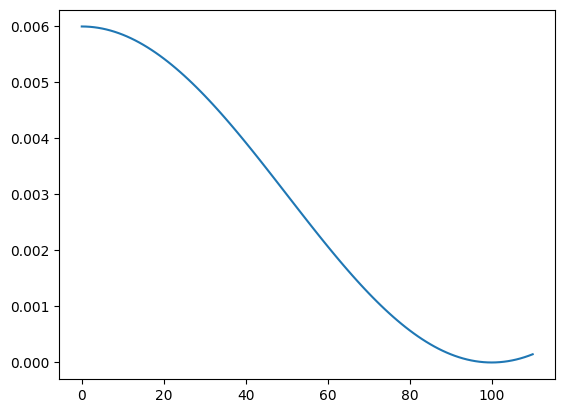

In [ ]:
sched_lrs(sched, 110)

总结下上述关于pytorch学习率调度器及其参数的内容

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

从刚才的代码里，核心涉及的内容可以总结为以下几点：

---

**1. PyTorch 内置的学习率调度器**

直观查看所有支持的学习率调度器：

```python
' '.join(o for o in dir(lr_scheduler) if o[0].isupper())
```

列出了比如 `CosineAnnealingLR`、`StepLR`、`OneCycleLR`、`ExponentialLR` 等常用的调度器。

---

**2. 调度器与优化器的关系**

调度器需要绑定一个优化器（`opt`），并知道总的步数（如 `T_max=100`）：

```python
sched = lr_scheduler.CosineAnnealingLR(opt, 100)
```

- `sched.base_lrs` → 基础学习率（初始时就是 `opt` 里的 `lr` 值）
- `sched.get_last_lr()` → 当前步骤的学习率

---

**3. 调度器的更新机制**

调度器需配合优化器的步进来调用：

```python
sched.optimizer.step()   # 模拟优化器更新（实际上可以 dummy）
sched.step()             # 调度器更新学习率
```

每次调用 `sched.step()`，调度器会根据其内置的规则修改 `opt.param_groups[0]['lr']` 的值。

---

**4. 可视化调度器变化**

通过一个简单辅助函数收集并绘制学习率曲线：

```python
def sched_lrs(sched, steps):
    lrs = [sched.get_last_lr()]
    for i in range(steps):
        sched.optimizer.step()
        sched.step()
        lrs.append(sched.get_last_lr())
    plt.plot(lrs)
```

调用 `sched_lrs(sched, 110)` 得到了 `CosineAnnealingLR` 的余弦退火曲线。

---

**要点总结：**

| 概念 | 说明 |
|--|--|
| `CosineAnnealingLR(opt, T_max)` | 让学习率按余弦曲线从初始值下降到 0，周期长度为 `T_max` |
| `get_last_lr()` | 返回当前步骤的学习率列表（每个参数组一个值） |
| `base_lrs` | 初始学习率列表 |
| 调度器本质工作 | 每一步修改 `opt.param_groups[k]['lr']` 的值 |

还有其他调度器或某个细节想继续了解吗？

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=11,657 | in=10,917 | out=740 | cached=70.3% | reasoning=214 | searches=0 | $0.0010`

</details>


训练时往往不知道哪个epoch是最佳性能，怎么设定T_max，以及sched.step为什么只修改opt.param_groups[0]['lr']，不修改其他groups

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题，两个都挺关键的。

---

**1. 不知道最佳 epoch 数时怎么办？**

确实，`CosineAnnealingLR(opt, T_max)` 需要你指定一个总步数，训练到那一步后学习率会降到 0。实际中常用几种做法：

- **设一个偏大的 T_max** — 比如你估计最多跑 100 个 epoch，就把 `T_max` 设成 100，训练中观察验证损失，提前早停即可。学习率降到 0 附近时通常模型已经收敛得差不多了。

- **用 `CosineAnnealingWarmRestarts`** — 它每 `T_0` 步重启一次学习率（跳回初始值），这样即使训练超了，学习率也不会卡在 0：

  ```python
  sched = CosineAnnealingWarmRestarts(opt, T_0=50)
  ```

- **用 `ReduceLROnPlateau`** — 它不需要提前设定总步数，而是监控验证损失，发现不再下降时才减小学习率，更适合"不知道什么时候最好"的情况。

  ```python
  sched = ReduceLROnPlateau(opt, mode='min', patience=5)
  # 每个 epoch 后调用
  sched.step(val_loss)
  ```

---

**2. `sched.step()` 真的只改第一个参数组吗？**

不会的，它**会修改所有参数组**。PyTorch 的调度器内部是这样实现的：

```python
def step(self):
    ...
    lrs = self.get_lr()
    for i, lr in enumerate(lrs):
        self.optimizer.param_groups[i]['lr'] = lr
```

也就是说，有多少个参数组，它就会遍历多少个，把每个组对应 `base_lrs[i]` 按比例缩放后写回去。

刚才代码里只看了 `pg = opt.param_groups[0]`，是因为默认只有一个参数组（所有参数用同一份学习率），所以只输出了 `pg['lr']`。如果定义了多个参数组（比如不同层用不同学习率），调度器会分别更新每个组的学习率。

---

可以试试加个实验看看：建两个不同 `lr` 的参数组，然后观察调度器是否同时更新它们。想试试吗？

<details class='token-usage-details' markdown='1'><summary>$0.0008</summary>

`total=12,035 | in=11,025 | out=1,010 | cached=84.8% | reasoning=508 | searches=0 | $0.0008`

</details>


业界更普遍使用哪些学习率调度器

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

业界用得最多的，说白了就是**三个主力选手**：

---

**1. `CosineAnnealingLR` / `CosineAnnealingWarmRestarts`**

- 目前非常流行，尤其在计算机视觉和一些 Transformer 类模型里
- 原因：余弦曲线平滑地降低学习率，训练初期高学习率帮助快速收敛，后期低学习率帮助精细调参
- `CosineAnnealingWarmRestarts` 还能周期性重启，适合训练周期长的任务
- 常见搭配：前面加几轮线性 warmup（学习率从 0 慢慢升到初始值），然后再开始余弦退火

---

**2. `OneCycleLR`**

- 在 NLP 和 CV 训练中都相当常用，来自 Leslie Smith 的论文
- 它遵循"先升后降"的循环策略：学习率先从很小的值升到一个较高的峰值，再余弦式下降回去
- 好处：训练快、收敛好，而且通常能允许你用更大的学习率，从而提高训练效率
- fastai 内部长期默认就是这个

---

**3. `ReduceLROnPlateau`**

- 可解释性强、调参简单，很多生产流水线喜欢用它
- 只要损失不再下降就减半学习率，不需要预先知道训练步数
- 适合验证指标波动大、训练长度不确定的场合（比如医疗和时间序列任务）

---

**简言之：**

| 场景 | 常用选择 |
|--|--|
| 确定总步数、模型是标准的 CNN / Transformer | `CosineAnnealingLR` + warmup |
| 想尽量省心、自动调节 | `ReduceLROnPlateau` |
| 追求速度和最大化性能 | `OneCycleLR` |

想深入了解某个的用法，或者看看它们的曲线对比吗？

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=11,998 | in=11,591 | out=407 | cached=87.2% | reasoning=26 | searches=0 | $0.0005`

</details>


### Scheduler callbacks

In [ ]:
#|export
class BaseSchedCB(Callback):
    def __init__(self, sched): self.sched = sched
    def before_fit(self, learn): self.schedo = self.sched(learn.opt)
    def _step(self, learn):
        if learn.training: self.schedo.step()

In [ ]:
#|export
class BatchSchedCB(BaseSchedCB):
    def after_batch(self, learn): self._step(learn)

In [ ]:
#|export
class HasLearnCB(Callback):
    def before_fit(self, learn): self.learn = learn 
    def after_fit(self, learn): self.learn = None

HasLearnCB的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`HasLearnCB` 的作用很简单：**让其他回调函数能拿到 `learn` 对象**。

具体来说：

```python
class HasLearnCB(Callback):
    def before_fit(self, learn): self.learn = learn 
    def after_fit(self, learn): self.learn = None
```

- **`before_fit`**：训练开始时，把 `learn`（即当前的 `Learner` 实例）保存到自身属性 `self.learn` 里。
- **`after_fit`**：训练结束后，把 `self.learn` 清空。

为什么需要这个？因为不是一个回调都能直接访问 `learn` 对象——有些工具类回调（比如 scheduler 回调）可能只知道自己有 `self.schedo`，但如果在训练过程中的某个时刻需要查询 `learn` 上的信息（比如当前 epoch 数、loss 值等），就可以通过 `HasLearnCB` 来拿到。不过更常见的做法是直接在回调定义时让框架注入 `learn`，所以这个类更像是一个辅助/兼容性的组件。

你想继续了解它是怎么被其他回调使用的吗？

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=11,008 | in=10,640 | out=368 | cached=95.0% | reasoning=128 | searches=0 | $0.0003`

</details>


In [ ]:
#|export
class RecorderCB(Callback):
    def __init__(self, **d): self.d = d
    def before_fit(self, learn):
        self.recs = {k:[] for k in self.d}
        self.pg = learn.opt.param_groups[0]
    
    def after_batch(self, learn):
        if not learn.training: return
        for k,v in self.d.items():
            self.recs[k].append(v(self))

    def plot(self):
        for k,v in self.recs.items():
            plt.plot(v, label=k)
            plt.legend()
            plt.show()

In [ ]:
def _lr(cb): return cb.pg['lr']

In [ ]:
len(dls.train)

59


In [ ]:
tmax = 5 * len(dls.train)
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=tmax)

In [ ]:
set_seed(42)
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
rec = RecorderCB(lr=_lr)
xtra = [BatchSchedCB(sched),rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(5)

accuracy,loss,epoch,train
0.807,0.523,0,train
0.859,0.382,0,eval
0.879,0.329,1,train
0.878,0.330,1,eval
0.895,0.281,2,train
0.887,0.303,2,eval
0.911,0.245,3,train
0.892,0.293,3,eval
0.918,0.226,4,train
0.896,0.282,4,eval


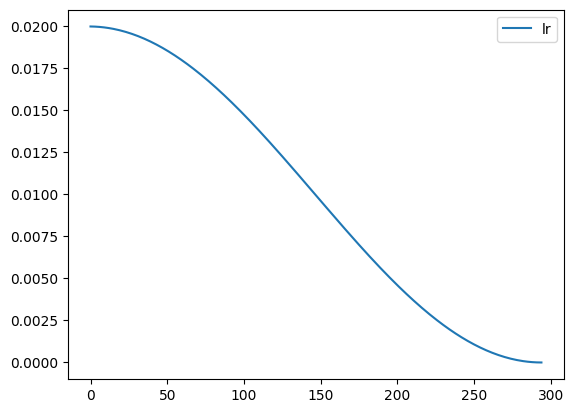

In [ ]:
rec.plot()

In [ ]:
#|export
class EpochSchedCB(BaseSchedCB):
    def after_epoch(self, learn): self._step(learn)

In [ ]:
sched = partial(lr_scheduler.CosineAnnealingLR, T_max=5)
set_seed(42)
xtra = [EpochSchedCB(sched),rec]
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
learn = TrainLearner(model, dls, F.cross_entropy, lr=2e-2, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(5)

accuracy,loss,epoch,train
0.807,0.522,0,train
0.856,0.378,0,eval
0.879,0.330,1,train
0.872,0.336,1,eval
0.897,0.280,2,train
0.885,0.318,2,eval
0.910,0.246,3,train
0.892,0.289,3,eval
0.920,0.219,4,train
0.900,0.276,4,eval


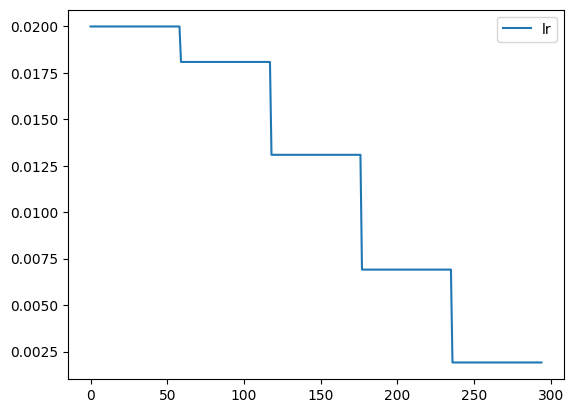

In [ ]:
rec.plot()

### 1cycle training

[Paper](https://arxiv.org/abs/1803.09820) by Leslie Smith.

In [ ]:
def _beta1(cb): return cb.pg['betas'][0]
rec = RecorderCB(lr=_lr, mom=_beta1)

In [ ]:
set_seed(42)
lr,epochs = 6e-2,5
model = get_model(act_gr, norm=nn.BatchNorm2d).apply(iw)
tmax = epochs * len(dls.train)
sched = partial(lr_scheduler.OneCycleLR, max_lr=lr, total_steps=tmax)
xtra = [BatchSchedCB(sched), rec]
learn = TrainLearner(model, dls, F.cross_entropy, lr=lr, cbs=cbs+xtra, opt_func=optim.AdamW)
learn.fit(epochs)

accuracy,loss,epoch,train
0.768,0.659,0,train
0.844,0.447,0,eval
0.860,0.383,1,train
0.851,0.416,1,eval
0.886,0.308,2,train
0.883,0.322,2,eval
0.907,0.248,3,train
0.897,0.280,3,eval
0.923,0.210,4,train
0.904,0.268,4,eval


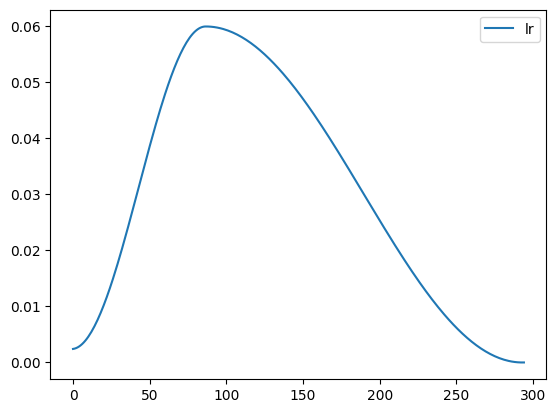

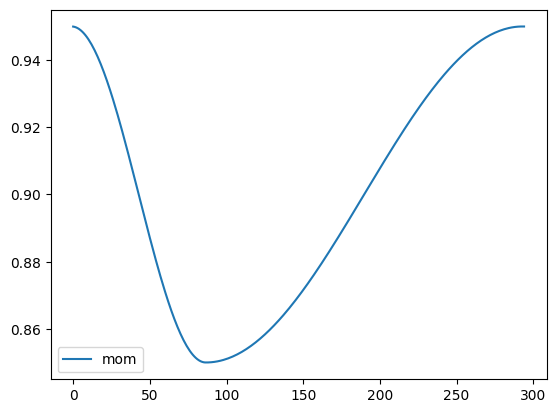

In [ ]:
rec.plot()

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()